In [94]:
import pandas as pd

df=pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    names=["label","message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [96]:
df.shape

(5572, 2)

In [98]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [100]:
df.isnull().sum()

label      0
message    0
dtype: int64

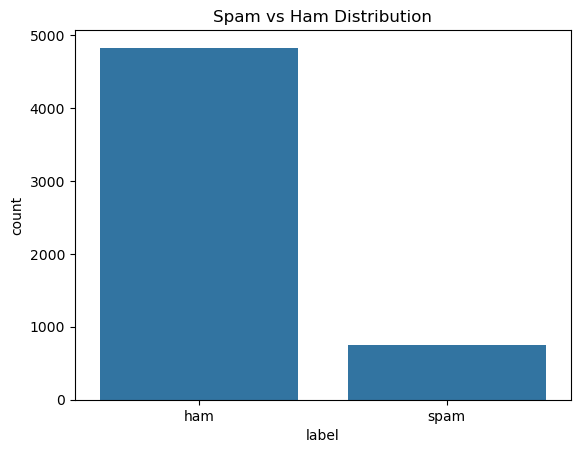

In [102]:
# class distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="label",
    data=df
)

plt.title("Spam vs Ham Distribution")
plt.show()

In [104]:
# converting labels to numbers

df["label"]=df["label"].map({
    "ham":0,
    "spam":1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [106]:
# text length feature

df["message_length"] = df["message"].apply(len)



In [108]:
df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


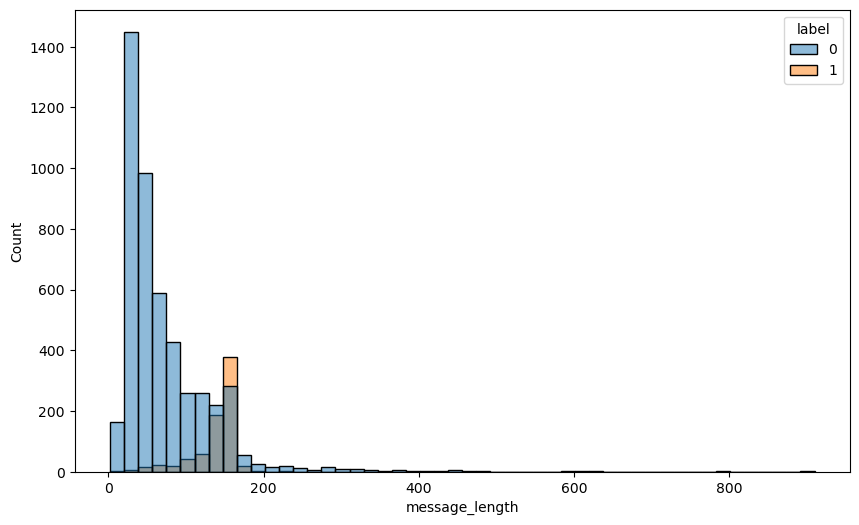

In [110]:
# comparing message lengths
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50
)

plt.show()

In [112]:
!pip install nltk

In [114]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sarjeeta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [116]:
import string

from nltk.corpus import stopwords

In [118]:
# cleaning function

def clean_text(text):
    text = str(text)
    text=text.lower()
    text= ''.join(
        char for char in text
        if char not in string.punctuation
    )
    words= text.split()
    words=[
        word
        for word in words
        if word not in stopwords.words('english')
    ]
    return " ".join(words)

In [120]:
sample="Congratulations!!! You won a FREE iphone."
print(clean_text(sample))


congratulations free iphone


In [122]:
df["clean_message"]= df["message"].apply(clean_text)

X=df["clean_message"]
y=df["label"]


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [126]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer= TfidfVectorizer()

X_train_tfidf= vectorizer.fit_transform(X_train)

X_test_tfidf= vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 8288)
(1115, 8288)


In [134]:
df[["message","clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [140]:
# Naive Bayes

from sklearn.naive_bayes import MultinomialNB
nb= MultinomialNB()
nb.fit(X_train_tfidf,y_train)

y_pred=nb.predict(X_test_tfidf)

In [142]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report
)

In [144]:

accuracy= accuracy_score(y_test,y_pred)

precision = precision_score(y_test, y_pred)

recall= recall_score(y_test, y_pred)

f1=f1_score(y_test,y_pred)

print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall: ",recall)
print("F1 Score: ",f1)

Accuracy:  0.9713004484304932
Precision:  1.0
Recall:  0.785234899328859
F1 Score:  0.8796992481203008


In [146]:
#confusion matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)

[[966   0]
 [ 32 117]]


In [148]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [152]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)
lr_pred=lr.predict(X_test_tfidf)

In [156]:
print("Accuracy: ",accuracy_score(y_test,lr_pred))
print("Precision: ",precision_score(y_test,lr_pred))
print("Recall: ",recall_score(y_test,lr_pred))
print("F1 Score: ",f1_score(y_test,lr_pred))

Accuracy:  0.9605381165919282
Precision:  0.972972972972973
Recall:  0.7248322147651006
F1 Score:  0.8307692307692308


In [158]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision,
        precision_score(y_test, lr_pred)
    ],
    "Recall": [
        recall,
        recall_score(y_test, lr_pred)
    ],
    "F1 Score": [
        f1,
        f1_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.971300,1.000000,0.785235,0.879699
1,Logistic Regression,0.960538,0.972973,0.724832,0.830769
